<a href="https://colab.research.google.com/github/Jaydenkaleb/Introduction-to-AI/blob/main/Assignment%2010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Load the necessary library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#load the dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sid321axn/amazon-alexa-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-alexa-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-alexa-reviews


In [4]:
#load the dataset
df = pd.read_csv("amazon_alexa.tsv", sep="\t")

In [ ]:
#Explore the dataset
print(df.head())
print(df.shape)
print(df.columns)

   rating       date         variation  \
0       5  31-Jul-18  Charcoal Fabric    
1       5  31-Jul-18  Charcoal Fabric    
2       4  31-Jul-18    Walnut Finish    
3       5  31-Jul-18  Charcoal Fabric    
4       5  31-Jul-18  Charcoal Fabric    

                                    verified_reviews  feedback  
0                                      Love my Echo!         1  
1                                          Loved it!         1  
2  Sometimes while playing a game, you can answer...         1  
3  I have had a lot of fun with this thing. My 4 ...         1  
4                                              Music         1  
(3150, 5)
Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback'], dtype='object')


In [ ]:
#print the number of null value for each  olumn
print(df.isnull().sum())

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


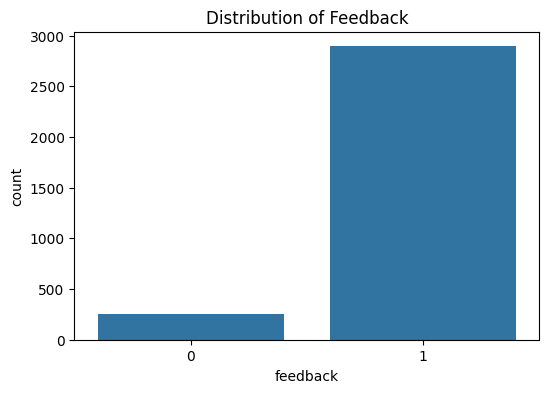

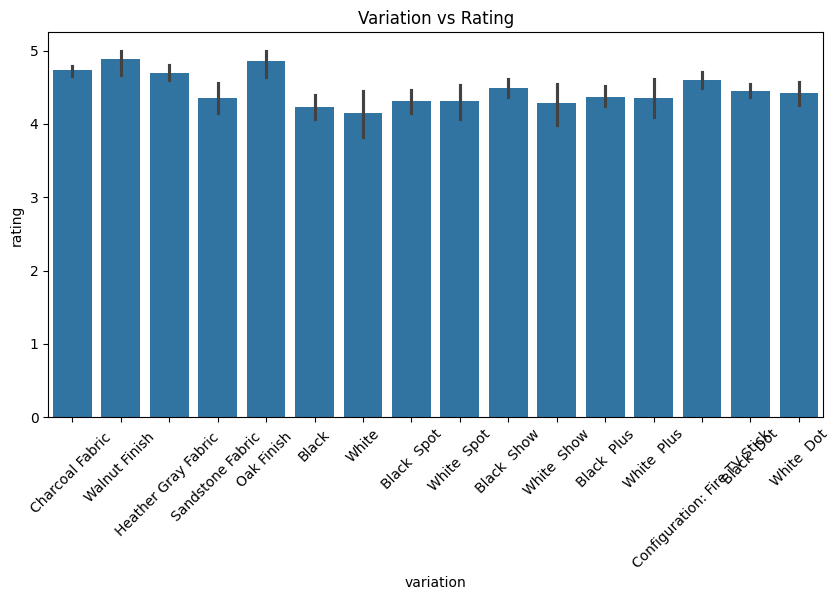

In [ ]:
#vivualizong using Seaborn count plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='feedback')
plt.title("Distribution of Feedback")
plt.show()

# Visualize the relationship between variations and ratings
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='variation', y='rating')
plt.title("Variation vs Rating")
plt.xticks(rotation=45)
plt.show()

Regarding the distribution of Feedback, the dataset contains both positive and negative customer reviews. 1 represents a positive review and 0 represents a negative review. Therefore there are about 250 negative feedbacks and 2,800 positive feedbacks.

Regarding the variation vs rating, all product variations have average ratings above 4 out of 5. indicating most customers generally rate Alexa product positively.

In [5]:
# Keep only the columns we care about
df = df[['verified_reviews', 'variation', 'feedback']]

# Make sure feedback is numeric (0/1)
df['feedback'] = df['feedback'].astype(int)

#this will drop the date and rating and only keep the above three columns

In [6]:
#One-Hot Encoding for 'variation'
variation_dummies = pd.get_dummies(df['variation'], prefix='var')
df = pd.concat([df, variation_dummies], axis=1)
df = df.drop('variation', axis=1)

In [7]:
#fill the missing verified reviews with "". Reason for filling is because when tokenizing, NAN is not a normal text string to be tokenize
df['verified_reviews'] = df['verified_reviews'].fillna("")

In [8]:
# Tokenization (CountVectorizer)
cv = CountVectorizer()
reviews_cv = cv.fit_transform(df['verified_reviews'])
reviews_df = pd.DataFrame(reviews_cv.toarray(), columns=cv.get_feature_names_out())

In [9]:
# Combine tokenized reviews with main dataframe
df = pd.concat([df, reviews_df], axis=1)

In [10]:
#drop the verified_reviews columns
df = df.drop('verified_reviews', axis=1)

In [ ]:
df.columns

Index(['feedback', 'var_Black', 'var_Black  Dot', 'var_Black  Plus',
       'var_Black  Show', 'var_Black  Spot', 'var_Charcoal Fabric ',
       'var_Configuration: Fire TV Stick', 'var_Heather Gray Fabric ',
       'var_Oak Finish ',
       ...
       'youtube', 'yr', 'yrs', 'yup', 'zero', 'zigbee', 'zonked', 'zzzz',
       'zzzzzzz', 'útil'],
      dtype='object', length=4061)

In [16]:
# Prepare data for modeling by split the data into features (X) and target (y)
X = df.drop('feedback', axis=1)
y = df['feedback']

In [17]:
y.head()

,feedback,feedback
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2520, 4059)
Testing data: (630, 4059)


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [35]:
X_train.columns

Index(['var_Black', 'var_Black  Dot', 'var_Black  Plus', 'var_Black  Show',
       'var_Black  Spot', 'var_Charcoal Fabric ',
       'var_Configuration: Fire TV Stick', 'var_Heather Gray Fabric ',
       'var_Oak Finish ', 'var_Sandstone Fabric ',
       ...
       'youtube', 'yr', 'yrs', 'yup', 'zero', 'zigbee', 'zonked', 'zzzz',
       'zzzzzzz', 'útil'],
      dtype='object', length=4059)

In [14]:
# Evaluate the model
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))

ValueError: multilabel-indicator is not supported

In [39]:
df.columns

Index(['feedback', 'var_Black', 'var_Black  Dot', 'var_Black  Plus',
       'var_Black  Show', 'var_Black  Spot', 'var_Charcoal Fabric ',
       'var_Configuration: Fire TV Stick', 'var_Heather Gray Fabric ',
       'var_Oak Finish ',
       ...
       'youtube', 'yr', 'yrs', 'yup', 'zero', 'zigbee', 'zonked', 'zzzz',
       'zzzzzzz', 'útil'],
      dtype='object', length=4061)

Hi Sorath, this has given me so much trouble and i still can't figure out why i have two feedback columns, i am unable to evaluate my model as such i can't continue the code. I already asked for iem for this and atthsi point i will submit and then find time to rewatch the recording as it seems i have not undertood the concept.